In [69]:
import numpy as np
import matplotlib.pylab as plt
import matplotlib
import math
import pandas as pd
from scipy import special
%matplotlib inline
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

def f(x):
    return x**6 - x - 1

def  fp(x):
    return 6*x**5 - 1

def newton(f,fp,p0,tol,Nmax):
  """
  Newton iteration.
  
  Inputs:
    f,fp - function and derivative
    p0   - initial guess for root
    tol  - iteration stops when p_n,p_{n+1} are within tol
    Nmax - max number of iterations
  Returns:
    p     - an array of the iterates
    pstar - the last iterate
    info  - success message
          - 0 if we met tol
          - 1 if we hit Nmax iterations (fail)
     
  """
  p = np.zeros(Nmax+1);
  p[0] = p0
  for it in range(Nmax):
      p1 = p0-f(p0)/fp(p0)
      p[it+1] = p1
      if (abs(p1-p0) < tol):
          pstar = p1
          info = 0
          return [p,pstar,info,it]
      p0 = p1
  pstar = p1
  info = 1
  return [p,pstar,info,it]

x0 = 2

p, pstar, ier, it = newton(f, fp, x0, 1e-10, 8)

# Accurate value of the root
alpha = 1.134724138401519

# Only keep the iterations that were actually used
p = p[:it+2]

# Calculate error
err = np.abs(p - alpha)

# Create table
newton_table = pd.DataFrame({
    'x_n': p,
    'Error': err
})

print(newton_table)
p = np.log(err[7]/err[6]) / np.log(err[6]/err[5])
print("Alpha =", p)
err_newton = err.copy()

        x_n         Error
0  2.000000  8.652759e-01
1  1.680628  5.459041e-01
2  1.430739  2.960148e-01
3  1.254971  1.202468e-01
4  1.161538  2.681429e-02
5  1.136353  1.629136e-03
6  1.134731  6.389942e-06
7  1.134724  9.870216e-11
8  1.134724  4.440892e-16
Alpha = 1.9992726108038403


In [71]:
def secant(f,p0,p1,tol,Nmax):
    """
    Secant iteration.
    Inputs:
    f,fp - function and derivative
    p0 - initial guess for root
    p1 - a second guess for the root
    tol - iteration stops when p_n,p_{n+1} are within tol
    Nmax - max number of iterations
    Returns:
    p - an array of the iterates
    pstar - the last iterate
    info - success message
    - 0 if we met tol
    - 1 if we hit Nmax iterations (fail)
    """
    p = np.zeros(Nmax+1)
    p[0] = p0
    p[1] = p1
    fp0 = f(p0)
    fp1 = f(p1)
    for it in range(1,Nmax):
        p2 = p1-fp1*(p1-p0)/(fp1-fp0)
        p[it+1] = p2
        if (abs(p1-p2) < tol):
            pstar = p2
            info = 0
            return [p,pstar,info,it]
        p0 = p1
        fp0 = fp1
        p1 = p2
        fp1 = f(p2)
    pstar = p2
    info = 1
    return [p,pstar,info,it]

x0 = 2
x1 = 1

p, pstar, ier, it = secant(f, x0, x1, 1e-10, 11)

alpha = 1.134724138401519

p = p[:it+2]

err = np.abs(p - alpha)

secant_table = pd.DataFrame({
    'x_n': p,
    'Error': err
})

print(secant_table)
p = np.log(err[8]/err[7]) / np.log(err[7]/err[6])
print("Alpha =", p)
err_secant = err.copy()

         x_n         Error
0   2.000000  8.652759e-01
1   1.000000  1.347241e-01
2   1.016129  1.185951e-01
3   1.190578  5.585363e-02
4   1.117656  1.706831e-02
5   1.132532  2.192588e-03
6   1.134817  9.266960e-05
7   1.134724  4.924528e-07
8   1.134724  1.103031e-10
9   1.134724  6.661338e-16
10  1.134724  4.440892e-16
Alpha = 1.60459893704408


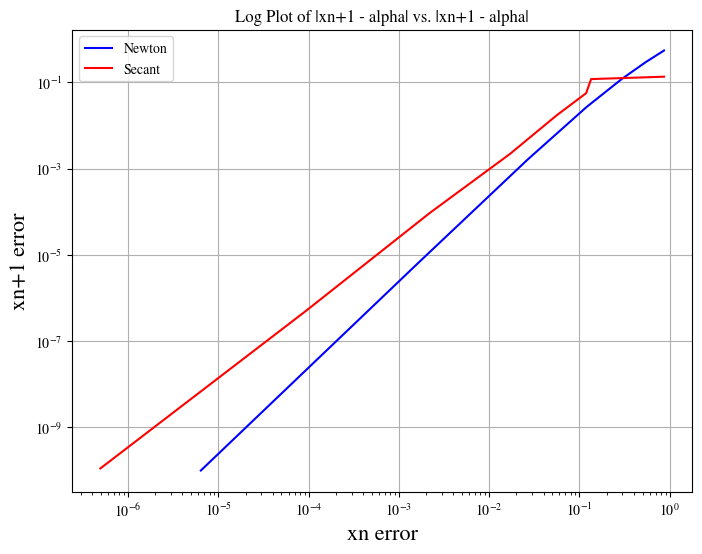

In [83]:
plt.figure(figsize=(8,6))

# Don't include errors at machine precision
mask_newton = (err_newton[:-1] > 1e-14) & (err_newton[1:] > 1e-14)
mask_secant = (err_secant[:-1] > 1e-14) & (err_secant[1:] > 1e-14)

# Newton
plt.loglog(err_newton[:-1][mask_newton],
           err_newton[1:][mask_newton],
           label='Newton', color = 'blue')

# Secant
plt.loglog(err_secant[:-1][mask_secant],
           err_secant[1:][mask_secant],
           label='Secant', color = 'red')

plt.xlabel('xn error', fontsize=16)
plt.ylabel('xn+1 error', fontsize=16)

plt.title('Log Plot of |xn+1 - alpha| vs. |xn+1 - alpha|')
plt.legend()
plt.grid(True)
plt.savefig('HW4_Q4.pdf')
plt.show()

In [86]:
def save_table_pdf(df, filename, title):
    fig, ax = plt.subplots(figsize=(8, 0.5 + 0.45*len(df)))

    # Remove axes
    ax.axis('off')

    # Format numbers for display
    display_df = df.copy()

    for col in display_df.columns:
        if col == 'Error':
            display_df[col] = display_df[col].map(lambda x: f'{x:.6e}')
        elif col == 'x_n':
            display_df[col] = display_df[col].map(lambda x: f'{x:.12f}')

    # Create table
    table = ax.table(
        cellText=display_df.values,
        colLabels=display_df.columns,
        cellLoc='center',
        loc='center'
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.4)

    plt.title(title, fontsize=14)

    # Save PDF
    plt.savefig(filename, format='pdf', bbox_inches='tight')

    plt.close()


# Save Newton table
save_table_pdf(
    newton_table,
    'newton_table.pdf',
    "Newton's Method"
)

# Save Secant table
save_table_pdf(
    secant_table,
    'secant_table.pdf',
    "Secant Method"
)